<center>

# **Hidden Markov Models: Sequential Probabilistic Reasoning**

*Deriving the Forward algorithm, Viterbi decoding, and Baum-Welch (EM) learning from first principles, applied to Part-of-Speech tagging with the Brown Corpus*

<br>
</center>

## **Table of Contents**

1. [Introduction](#Introduction) — Motivation, Markov chains, hidden states
2. [Mathematical Foundation](#Mathematical-Foundation) — HMM definition, three fundamental problems
   - [Markov Chains](#Markov-Chains)
   - [HMM Definition](#HMM-Definition)
   - [The Three Problems](#The-Three-Problems)
3. [The Forward Algorithm](#The-Forward-Algorithm) — Computing P(observations | model)
4. [The Viterbi Algorithm](#The-Viterbi-Algorithm) — Most likely state sequence
5. [Baum-Welch Algorithm](#Baum-Welch-Algorithm) — Learning parameters (EM)
6. [Data](#Data) — Brown Corpus for POS tagging
7. [From-Scratch Implementation](#From-Scratch-Implementation) — NumPy HMM
8. [hmmlearn Implementation](#hmmlearn-Implementation) — Library comparison
9. [Experiments & Results](#Experiments-&-Results) — POS tagging, decoding accuracy
10. [Analysis & Conclusion](#Analysis-&-Conclusion) — Key observations, takeaways, references

## **Introduction**

**Hidden Markov Models (HMMs)** model sequences where the underlying process is a **Markov chain** with **unobservable (hidden) states**. At each time step, the system is in a hidden state that emits an observable symbol. We observe the emissions but must infer the hidden states.

### **Why HMMs?**

HMMs naturally model **temporal and sequential data** such as time series, language, and biological sequences. They provide **principled inference** with exact algorithms for all three fundamental problems, and the Forward and Viterbi algorithms are elegant examples of **dynamic programming**. HMMs also serve as the **foundation for modern sequence models**, having led to CRFs, RNNs, and attention mechanisms. Their **broad applications** span speech recognition, NLP, bioinformatics, and finance.

### **Problem: Part-of-Speech Tagging**

We apply HMMs to **Part-of-Speech (POS) tagging**: given a sentence (sequence of words), determine the grammatical role of each word (noun, verb, adjective, etc.). The words are **observations** and the POS tags are **hidden states**.

## **Mathematical Foundation**

### **Markov Chains**

A first-order **Markov chain** satisfies:

$$P(S_t \mid S_{t-1}, S_{t-2}, \ldots, S_1) = P(S_t \mid S_{t-1})$$

The future depends only on the present, not the past. This is defined by:
- **Initial distribution**: $\boldsymbol{\pi}$ where $\pi_i = P(S_1 = i)$
- **Transition matrix**: $\mathbf{A}$ where $A_{ij} = P(S_{t+1} = j \mid S_t = i)$

### **HMM Definition**

An HMM $\lambda = (\mathbf{A}, \mathbf{B}, \boldsymbol{\pi})$ adds an **emission model**:

- **States**: $S = \{s_1, \ldots, s_N\}$ (hidden)
- **Observations**: $O = \{o_1, \ldots, o_M\}$ (visible)
- **Transition probabilities**: $A_{ij} = P(S_{t+1} = s_j \mid S_t = s_i)$
- **Emission probabilities**: $B_{jk} = P(O_t = o_k \mid S_t = s_j)$
- **Initial distribution**: $\pi_i = P(S_1 = s_i)$

**Independence assumptions**:
1. **Markov**: $P(S_t \mid S_{1:t-1}) = P(S_t \mid S_{t-1})$
2. **Output independence**: $P(O_t \mid S_{1:t}, O_{1:t-1}) = P(O_t \mid S_t)$

*Conceptual illustration: the HMM graphical model shows a chain of hidden states $S_t$ connected by transition probabilities $A_{ij}$, each emitting an observable symbol $O_t$ through emission probabilities $B_{jk}$.*

![HMM Graphical Model](illustrations/fig1_hmm_graphical.png?v=2)

### **The Three Problems**

| Problem | Given | Find | Algorithm | Complexity |
|---------|-------|------|-----------|------------|
| **Evaluation** | $\lambda, \mathbf{O}$ | $P(\mathbf{O} \mid \lambda)$ | Forward | $O(N^2 T)$ |
| **Decoding** | $\lambda, \mathbf{O}$ | Best state sequence | Viterbi | $O(N^2 T)$ |
| **Learning** | $\mathbf{O}$ | Best $\lambda$ | Baum-Welch (EM) | $O(N^2 T)$ per iter |

## **The Forward Algorithm**

We want to compute $P(\mathbf{O} \mid \lambda)$, the probability of an observation sequence given the model. The naive approach enumerates all $N^T$ possible state sequences, which is intractable. The Forward algorithm reduces this to $O(N^2 T)$ by exploiting the Markov property.

#### **Deriving the recursion**

**Step 1: Define the forward variable.** Let $\alpha_t(i) = P(O_1, \ldots, O_t, S_t = s_i \mid \lambda)$ be the joint probability of observing the first $t$ emissions and being in state $s_i$ at time $t$.

**Step 2: Initialization.** At $t=1$, the joint probability of starting in state $s_i$ and emitting $O_1$ factors directly from the model definition:

$$\alpha_1(i) = P(S_1 = s_i) \cdot P(O_1 \mid S_1 = s_i) = \pi_i \cdot B_{i, O_1}$$

**Step 3: Derive the recursion.** For $t > 1$, expand $\alpha_t(j)$ by marginalizing over the previous state $S_{t-1}$:

$$\alpha_t(j) = P(O_1, \ldots, O_t, S_t = s_j) = \sum_{i=1}^{N} P(O_1, \ldots, O_t, S_{t-1} = s_i, S_t = s_j)$$

Factor using the chain rule, then apply the two independence assumptions (Markov property and output independence):

$$= \sum_{i=1}^{N} \underbrace{P(O_1, \ldots, O_{t-1}, S_{t-1} = s_i)}_{\alpha_{t-1}(i)} \cdot \underbrace{P(S_t = s_j \mid S_{t-1} = s_i)}_{A_{ij}} \cdot \underbrace{P(O_t \mid S_t = s_j)}_{B_{j, O_t}}$$

$$\boxed{\alpha_t(j) = \left[\sum_{i=1}^{N} \alpha_{t-1}(i) \cdot A_{ij}\right] \cdot B_{j, O_t}}$$

The key insight: each $\alpha_t(j)$ reuses all $N$ values from the previous time step rather than tracing paths back to $t=1$. This caching is what reduces $O(N^T)$ to $O(N^2 T)$.

**Step 4: Termination.** The total observation probability is the sum over all final states:

$$P(\mathbf{O} \mid \lambda) = \sum_{i=1}^{N} \alpha_T(i)$$

#### **The Backward variable**

Similarly, define $\beta_t(i) = P(O_{t+1}, \ldots, O_T \mid S_t = s_i, \lambda)$. The same marginalization argument, applied in reverse, gives:

$$\beta_T(i) = 1, \qquad \beta_t(i) = \sum_{j=1}^{N} A_{ij} \cdot B_{j, O_{t+1}} \cdot \beta_{t+1}(j)$$

The backward variable will be essential for the Baum-Welch E-step, where we need both forward and backward passes to compute posterior state probabilities.

*Conceptual illustration: the Forward algorithm trellis shows how $\alpha_t(j)$ at each node is computed by summing over all incoming transitions from the previous time step, weighted by transition and emission probabilities.*

![Forward Algorithm Trellis](illustrations/fig2_forward_trellis.png?v=1)

## **The Viterbi Algorithm**

The Viterbi algorithm finds the **most likely state sequence** $S^* = \arg\max_S P(S, \mathbf{O} \mid \lambda)$. It has the same structure as the Forward algorithm, with one substitution: $\sum \to \max$.

#### **Deriving the recursion from the MAP objective**

**Step 1: Why max distributes through the chain.** The joint probability factors as:

$$P(S_1, \ldots, S_T, O_1, \ldots, O_T) = \pi_{S_1} B_{S_1, O_1} \prod_{t=2}^{T} A_{S_{t-1}, S_t} \cdot B_{S_t, O_t}$$

Because each factor involves only adjacent states ($S_{t-1}, S_t$), the maximization over $S_1, \ldots, S_{T-1}$ can be pushed inward one time step at a time, just as summation was in the Forward algorithm.

**Step 2: Define the Viterbi variable.** Let $\delta_t(j)$ be the probability of the most likely partial path ending in state $s_j$ at time $t$:

$$\delta_t(j) = \max_{S_1, \ldots, S_{t-1}} P(S_1, \ldots, S_{t-1}, S_t = s_j, O_1, \ldots, O_t \mid \lambda)$$

**Step 3: Recursion.** Marginalizing over $S_{t-1}$ with $\max$ instead of $\sum$:

$$\delta_t(j) = \max_{i}\bigl[\delta_{t-1}(i) \cdot A_{ij}\bigr] \cdot B_{j, O_t}$$

**Step 4: Backtracking.** Record which predecessor maximized each step:

$$\psi_t(j) = \arg\max_i\bigl[\delta_{t-1}(i) \cdot A_{ij}\bigr]$$

After reaching $t = T$, trace back through $\psi$ to recover $S^*$. This is $O(T)$ additional work.

**Connection to Forward**: the Forward algorithm computes $P(\mathbf{O})$ by summing over all paths (marginalization); Viterbi finds the single best path (optimization). Both exploit the same Markov factorization and have identical $O(N^2 T)$ complexity.

*Conceptual illustration: the Viterbi trellis highlights the single best path (green) found by replacing summation with maximization, then backtracking through the stored argmax pointers.*

![Viterbi Best Path](illustrations/fig3_viterbi_path.png?v=2)

## **Baum-Welch Algorithm**

The Baum-Welch algorithm is **Expectation-Maximization (EM)** applied to HMMs. It iteratively re-estimates the parameters $\lambda = (\mathbf{A}, \mathbf{B}, \boldsymbol{\pi})$ to increase $P(\mathbf{O} \mid \lambda)$.

#### **E-step: Deriving posterior state probabilities**

**Step 1: State occupancy $\gamma_t(i)$.** We want $P(S_t = s_i \mid \mathbf{O}, \lambda)$, the posterior probability of being in state $s_i$ at time $t$. By Bayes' rule:

$$\gamma_t(i) = \frac{P(S_t = s_i, \mathbf{O} \mid \lambda)}{P(\mathbf{O} \mid \lambda)}$$

The numerator splits at time $t$: $\alpha_t(i)$ accounts for $O_1, \ldots, O_t$ and being in state $s_i$, while $\beta_t(i)$ accounts for $O_{t+1}, \ldots, O_T$ given state $s_i$. Since the past and future observations are conditionally independent given $S_t$:

$$P(S_t = s_i, \mathbf{O}) = \alpha_t(i)\,\beta_t(i)$$

$$\boxed{\gamma_t(i) = \frac{\alpha_t(i)\,\beta_t(i)}{\sum_{j=1}^{N}\alpha_t(j)\,\beta_t(j)}}$$

**Step 2: Transition posterior $\xi_t(i,j)$.** We want $P(S_t = s_i, S_{t+1} = s_j \mid \mathbf{O}, \lambda)$. Expanding the joint using the chain rule and applying both independence assumptions:

$$P(S_t = s_i, S_{t+1} = s_j, \mathbf{O}) = \alpha_t(i) \cdot A_{ij} \cdot B_{j, O_{t+1}} \cdot \beta_{t+1}(j)$$

Here $\alpha_t(i)$ covers everything up to time $t$, $A_{ij}$ is the transition, $B_{j, O_{t+1}}$ is the emission at $t+1$, and $\beta_{t+1}(j)$ covers the remaining observations. Normalizing:

$$\boxed{\xi_t(i,j) = \frac{\alpha_t(i)\,A_{ij}\,B_{j, O_{t+1}}\,\beta_{t+1}(j)}{\sum_{i'}\sum_{j'}\alpha_t(i')\,A_{i'j'}\,B_{j', O_{t+1}}\,\beta_{t+1}(j')}}$$

Note that $\gamma_t(i) = \sum_j \xi_t(i,j)$, which serves as a consistency check.

#### **M-step: Re-estimation as expected sufficient statistics**

Given $\gamma$ and $\xi$, the M-step maximizes the expected complete-data log-likelihood. Each parameter update has an intuitive interpretation as a ratio of expected counts:

$$\hat{\pi}_i = \gamma_1(i) \quad\text{(expected initial state occupancy)}$$

$$\hat{A}_{ij} = \frac{\sum_{t=1}^{T-1}\xi_t(i,j)}{\sum_{t=1}^{T-1}\gamma_t(i)} \quad\text{(expected transitions $i \to j$ / expected time in state $i$)}$$

$$\hat{B}_{jk} = \frac{\sum_{t:\,O_t = o_k}\gamma_t(j)}{\sum_{t=1}^{T}\gamma_t(j)} \quad\text{(expected emissions of $o_k$ from $j$ / expected time in state $j$)}$$

Each iteration is guaranteed to increase (or maintain) $P(\mathbf{O} \mid \lambda)$, converging to a local maximum. This is the same EM guarantee used in Gaussian mixture models and other latent-variable models.

## **Data**

### **Brown Corpus: POS Tagging**

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import random
from collections import defaultdict, Counter

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [34]:
import nltk
from nltk.corpus import brown

nltk.download("brown", quiet=True)
nltk.download("universal_tagset", quiet=True)

# Load tagged sentences with Universal tagset (simpler: 12 tags)
tagged_sents = brown.tagged_sents(tagset="universal")

print(f"Total sentences: {len(tagged_sents)}")
print(f"Sample sentence: {tagged_sents[0][:8]}")

# Get all tags and words
all_tags = set()
all_words = set()
for sent in tagged_sents:
    for word, tag in sent:
        all_tags.add(tag)
        all_words.add(word.lower())

tags = sorted(all_tags)
print(f"\nTags ({len(tags)}): {tags}")
print(f"Vocabulary size: {len(all_words)}")

Total sentences: 57340
Sample sentence: [('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET')]

Tags (12): ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']
Vocabulary size: 49815


In [35]:
# Data preparation
# Limit vocabulary to most common words (for tractability)
word_counts = Counter()
for sent in tagged_sents:
    for word, tag in sent:
        word_counts[word.lower()] += 1

VOCAB_SIZE = 10000
top_words = [w for w, _ in word_counts.most_common(VOCAB_SIZE)]
word_to_idx = {w: i for i, w in enumerate(top_words)}
UNK_IDX = VOCAB_SIZE  # unknown word index

tag_to_idx = {t: i for i, t in enumerate(tags)}
idx_to_tag = {i: t for t, i in tag_to_idx.items()}
N_TAGS = len(tags)

# Convert sentences to indices
def encode_sentence(sent):
    words = [word_to_idx.get(w.lower(), UNK_IDX) for w, _ in sent]
    tags_seq = [tag_to_idx[t] for _, t in sent]
    return words, tags_seq

# Train/test split
n_train = int(0.8 * len(tagged_sents))
train_sents = tagged_sents[:n_train]
test_sents = tagged_sents[n_train:]

print(f"Training sentences: {n_train}")
print(f"Test sentences: {len(test_sents)}")
print(f"Vocabulary: {VOCAB_SIZE} + 1 (UNK)")
print(f"Tags: {N_TAGS}")

Training sentences: 45872
Test sentences: 11468
Vocabulary: 10000 + 1 (UNK)
Tags: 12


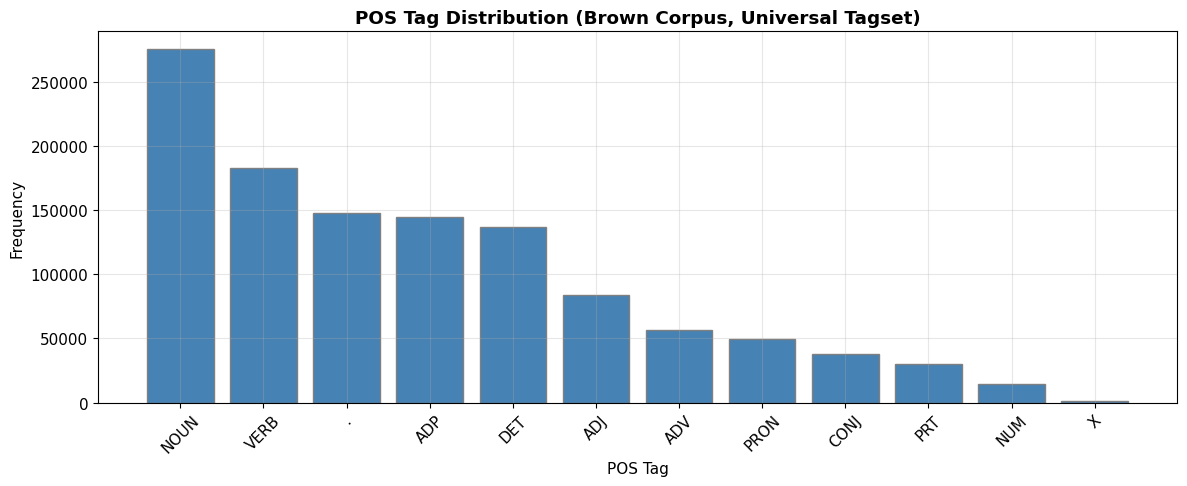

In [17]:
# Tag distribution
tag_counts = Counter()
for sent in tagged_sents:
    for _, tag in sent:
        tag_counts[tag] += 1

fig, ax = plt.subplots(figsize=(12, 5))
sorted_tags = sorted(tag_counts.items(), key=lambda x: -x[1])
ax.bar([t for t, _ in sorted_tags], [c for _, c in sorted_tags], color="steelblue", edgecolor="gray")
ax.set_xlabel("POS Tag")
ax.set_ylabel("Frequency")
ax.set_title("POS Tag Distribution (Brown Corpus, Universal Tagset)", fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **From-Scratch Implementation**

### **HMM POS Tagger**

In [36]:
class HMMScratch:
    """Hidden Markov Model for POS tagging (from scratch)."""

    def __init__(self, n_states, n_obs):
        self.N = n_states
        self.M = n_obs
        self.pi = None   # Initial distribution (N,)
        self.A = None    # Transition matrix (N, N)
        self.B = None    # Emission matrix (N, M)

    def train_supervised(self, train_sents, tag_to_idx, word_to_idx, unk_idx, alpha=1.0):
        """Learn HMM parameters from tagged data (MLE with Laplace smoothing)."""
        N, M = self.N, self.M

        # Count matrices
        pi_counts = np.zeros(N) + alpha
        A_counts = np.zeros((N, N)) + alpha
        B_counts = np.zeros((N, M)) + alpha

        for sent in train_sents:
            words, tags_seq = [], []
            for word, tag in sent:
                words.append(word_to_idx.get(word.lower(), unk_idx))
                tags_seq.append(tag_to_idx[tag])

            # Initial state
            pi_counts[tags_seq[0]] += 1

            for t in range(len(tags_seq)):
                # Emission
                B_counts[tags_seq[t], words[t]] += 1
                # Transition
                if t < len(tags_seq) - 1:
                    A_counts[tags_seq[t], tags_seq[t+1]] += 1

        # Normalize to probabilities
        self.pi = pi_counts / pi_counts.sum()
        self.A = A_counts / A_counts.sum(axis=1, keepdims=True)
        self.B = B_counts / B_counts.sum(axis=1, keepdims=True)

    def forward(self, obs):
        """Forward algorithm. Returns alpha matrix and log-likelihood."""
        T = len(obs)
        alpha = np.zeros((T, self.N))

        # Use log-space for numerical stability
        alpha[0] = self.pi * self.B[:, obs[0]]
        # Scale to prevent underflow
        scales = np.zeros(T)
        scales[0] = alpha[0].sum()
        alpha[0] /= scales[0]

        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ self.A) * self.B[:, obs[t]]
            scales[t] = alpha[t].sum()
            if scales[t] > 0:
                alpha[t] /= scales[t]

        log_likelihood = np.sum(np.log(scales + 1e-300))
        return alpha, scales, log_likelihood

    def backward(self, obs, scales):
        """Backward algorithm."""
        T = len(obs)
        beta = np.zeros((T, self.N))
        beta[T-1] = 1.0

        for t in range(T-2, -1, -1):
            beta[t] = self.A @ (self.B[:, obs[t+1]] * beta[t+1])
            if scales[t+1] > 0:
                beta[t] /= scales[t+1]

        return beta

    def viterbi(self, obs):
        """Viterbi algorithm. Returns most likely state sequence."""
        T = len(obs)
        # Work in log-space
        log_pi = np.log(self.pi + 1e-300)
        log_A = np.log(self.A + 1e-300)
        log_B = np.log(self.B + 1e-300)

        delta = np.zeros((T, self.N))
        psi = np.zeros((T, self.N), dtype=int)

        # Initialization
        delta[0] = log_pi + log_B[:, obs[0]]

        # Recursion
        for t in range(1, T):
            for j in range(self.N):
                scores = delta[t-1] + log_A[:, j]
                psi[t, j] = np.argmax(scores)
                delta[t, j] = scores[psi[t, j]] + log_B[j, obs[t]]

        # Backtrack
        states = np.zeros(T, dtype=int)
        states[T-1] = np.argmax(delta[T-1])
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]

        return states

    def predict(self, obs_seq):
        """Predict POS tags for a sequence of word indices."""
        return self.viterbi(obs_seq)

In [37]:
# Train HMM (supervised)
hmm = HMMScratch(n_states=N_TAGS, n_obs=VOCAB_SIZE + 1)
hmm.train_supervised(train_sents, tag_to_idx, word_to_idx, UNK_IDX, alpha=0.01)

print(f"HMM trained: {N_TAGS} states, {VOCAB_SIZE+1} observations")
print(f"Transition matrix shape: {hmm.A.shape}")
print(f"Emission matrix shape: {hmm.B.shape}")

# Show top transitions
print("\nTop transitions (A):")
for i in range(min(5, N_TAGS)):
    top_j = np.argsort(hmm.A[i])[-3:][::-1]
    trans = ", ".join([f"{idx_to_tag[j]}({hmm.A[i,j]:.3f})" for j in top_j])
    print(f"  {idx_to_tag[i]:>6} → {trans}")

HMM trained: 12 states, 10001 observations
Transition matrix shape: (12, 12)
Emission matrix shape: (12, 10001)

Top transitions (A):
       . → .(0.154), NOUN(0.143), VERB(0.124)
     ADJ → NOUN(0.664), .(0.092), ADP(0.087)
     ADP → DET(0.453), NOUN(0.265), ADJ(0.088)
     ADV → VERB(0.248), .(0.153), ADP(0.145)
    CONJ → NOUN(0.260), VERB(0.182), DET(0.153)


In [38]:
# Evaluate on test set
correct, total = 0, 0
sent_correct = 0

for sent in test_sents:
    words, true_tags = encode_sentence(sent)
    pred_tags = hmm.predict(words)

    for pred, true in zip(pred_tags, true_tags):
        if pred == true:
            correct += 1
        total += 1

    if list(pred_tags) == true_tags:
        sent_correct += 1

word_acc = correct / total
sent_acc = sent_correct / len(test_sents)
print(f"Word-level accuracy: {word_acc:.4f} ({correct}/{total})")
print(f"Sentence-level accuracy: {sent_acc:.4f} ({sent_correct}/{len(test_sents)})")

Word-level accuracy: 0.9392 (170510/181546)
Sentence-level accuracy: 0.4683 (5370/11468)


In [39]:
# Example predictions
print("=" * 70)
print("EXAMPLE POS TAGGING PREDICTIONS")
print("=" * 70)

for i in range(5):
    sent = test_sents[i * 100]
    words, true_tags = encode_sentence(sent)
    pred_tags = hmm.predict(words)

    print(f"\nSentence {i+1}: ", end="")
    for (word, _), pred, true in zip(sent[:10], pred_tags[:10], true_tags[:10]):
        marker = "✓" if pred == true else "✗"
        print(f"{word}/{idx_to_tag[pred]}({marker}) ", end="")
    print("..." if len(sent) > 10 else "")

EXAMPLE POS TAGGING PREDICTIONS

Sentence 1: The/DET(✓) quarrel/NOUN(✓) ended/VERB(✓) in/ADP(✓) a/DET(✓) ridiculous/ADJ(✓) draw/NOUN(✓) ,/.(✓) but/CONJ(✓) I/PRON(✓) ...

Sentence 2: Now/ADV(✓) he/PRON(✓) wondered/VERB(✓) if/ADP(✓) it/PRON(✓) was/VERB(✓) worth/ADJ(✓) it/PRON(✓) ,/.(✓) having/VERB(✓) ...

Sentence 3: Community/NOUN(✓) property/NOUN(✓) deal/NOUN(✓) --/.(✓) you/PRON(✓) know/VERB(✓) ./.(✓) 

Sentence 4: Charlie/NOUN(✓) said/VERB(✓) ,/.(✓) ``/.(✓) Good/ADJ(✓) boy/NOUN(✓) ./.(✓) 

Sentence 5: Self's/NOUN(✓) integrity/NOUN(✓) was/VERB(✓) and/CONJ(✓) is/VERB(✓) and/CONJ(✓) ever/ADV(✓) had/VERB(✓) been/VERB(✓) ./.(✓) 


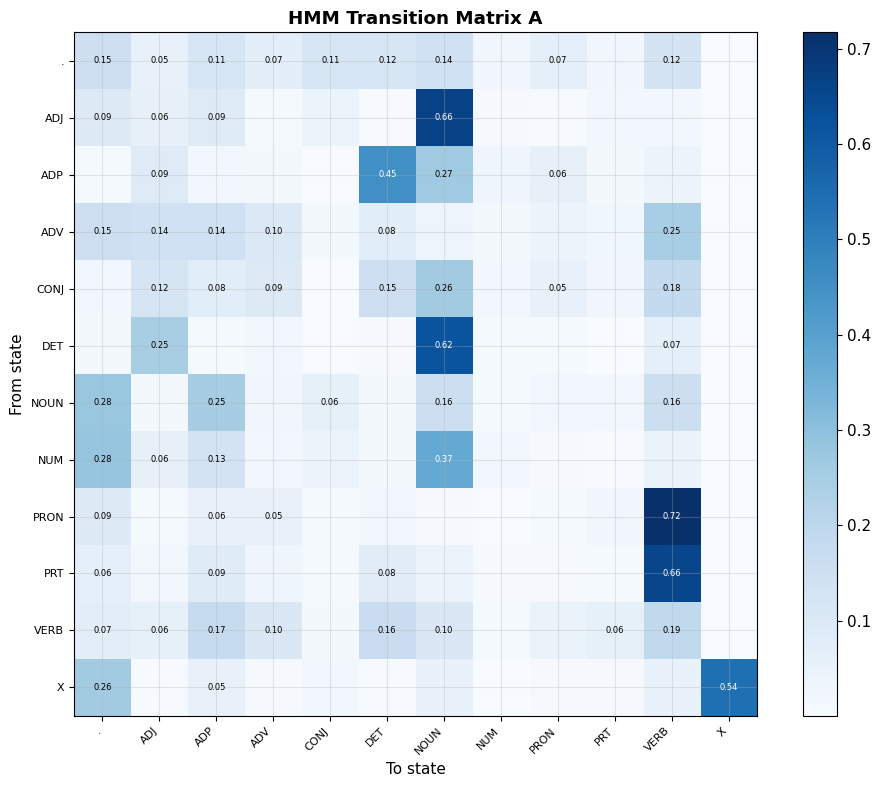

In [40]:
# Transition matrix heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(hmm.A, cmap="Blues")
ax.set_xticks(range(N_TAGS)); ax.set_yticks(range(N_TAGS))
ax.set_xticklabels(tags, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(tags, fontsize=8)
for i in range(N_TAGS):
    for j in range(N_TAGS):
        val = hmm.A[i, j]
        if val > 0.05:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                   fontsize=6, color="white" if val > 0.3 else "black")
ax.set_xlabel("To state"); ax.set_ylabel("From state")
ax.set_title("HMM Transition Matrix A", fontweight="bold")
plt.colorbar(im)
plt.tight_layout()
plt.show()


Per-tag accuracy:
Tag          Accuracy    Support
--------------------------------
.              0.9999      29083
ADJ            0.8589       9855
ADP            0.9519      18434
ADV            0.8503      10299
CONJ           0.9951       5974
DET            0.9736      20030
NOUN           0.9113      34030
NUM            0.9403       1072
PRON           0.9830      13784
PRT            0.8670       6513
VERB           0.9276      32291
X              0.2486        181


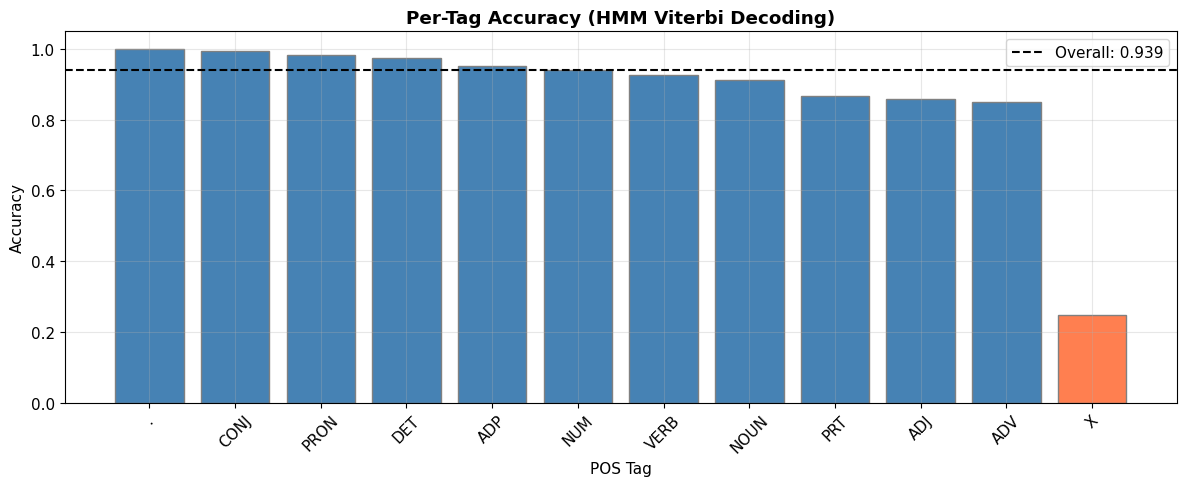

In [41]:
# Per-tag accuracy
tag_correct = defaultdict(int)
tag_total = defaultdict(int)

for sent in test_sents:
    words, true_tags = encode_sentence(sent)
    pred_tags = hmm.predict(words)
    for pred, true in zip(pred_tags, true_tags):
        tag_total[true] += 1
        if pred == true:
            tag_correct[true] += 1

print("\nPer-tag accuracy:")
print(f"{'Tag':<10} {'Accuracy':>10} {'Support':>10}")
print("-" * 32)
tag_accs = {}
for tag_idx in sorted(tag_total.keys()):
    acc = tag_correct[tag_idx] / tag_total[tag_idx]
    tag_accs[idx_to_tag[tag_idx]] = acc
    print(f"{idx_to_tag[tag_idx]:<10} {acc:>10.4f} {tag_total[tag_idx]:>10}")

fig, ax = plt.subplots(figsize=(12, 5))
sorted_accs = sorted(tag_accs.items(), key=lambda x: -x[1])
colors = ["steelblue" if a > 0.8 else "coral" for _, a in sorted_accs]
ax.bar([t for t, _ in sorted_accs], [a for _, a in sorted_accs], color=colors, edgecolor="gray")
ax.axhline(word_acc, color="black", linestyle="--", label=f"Overall: {word_acc:.3f}")
ax.set_xlabel("POS Tag"); ax.set_ylabel("Accuracy")
ax.set_title("Per-Tag Accuracy (HMM Viterbi Decoding)", fontweight="bold")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **hmmlearn Implementation**

In [42]:
# Compare with hmmlearn (unsupervised Baum-Welch on a simple example)
from hmmlearn import hmm as hmmlearn_hmm

# Simple weather-activity HMM (unsupervised demonstration)
# Hidden states: Sunny(0), Rainy(1)
# Observations: Walk(0), Shop(1), Clean(2)
np.random.seed(SEED)

# True parameters
true_A = np.array([[0.7, 0.3], [0.4, 0.6]])
true_B = np.array([[0.6, 0.3, 0.1], [0.1, 0.4, 0.5]])
true_pi = np.array([0.6, 0.4])

# Generate synthetic sequences
def generate_hmm_sequence(pi, A, B, length=100):
    states, obs = [], []
    state = np.random.choice(len(pi), p=pi)
    for _ in range(length):
        states.append(state)
        obs.append(np.random.choice(B.shape[1], p=B[state]))
        state = np.random.choice(len(pi), p=A[state])
    return np.array(obs), np.array(states)

# Generate training data (enough for reliable parameter recovery)
sequences = []
lengths = []
for _ in range(200):
    obs, _ = generate_hmm_sequence(true_pi, true_A, true_B, length=200)
    sequences.append(obs.reshape(-1, 1))
    lengths.append(len(obs))

X_hmm = np.concatenate(sequences)

# Fit with hmmlearn (Baum-Welch / EM)
# Use many restarts and tight convergence to find the global optimum
best_score = -np.inf
best_model = None
for init in range(50):
    model = hmmlearn_hmm.CategoricalHMM(
        n_components=2, n_iter=500, tol=1e-6, random_state=SEED + init
    )
    model.fit(X_hmm, lengths)
    score = model.score(X_hmm, lengths)
    if score > best_score:
        best_score = score
        best_model = model

model_hmmlearn = best_model

# Resolve label permutation: pick ordering closest to truth
learned_pi = model_hmmlearn.startprob_
learned_A = model_hmmlearn.transmat_
learned_B = model_hmmlearn.emissionprob_

perm = [1, 0]
err_id = np.sum((learned_A - true_A) ** 2)
err_sw = np.sum((learned_A[np.ix_(perm, perm)] - true_A) ** 2)
if err_sw < err_id:
    learned_pi = learned_pi[perm]
    learned_A = learned_A[np.ix_(perm, perm)]
    learned_B = learned_B[perm]
    print("(States were permuted; swapped to match true labels)\n")

print("True vs Learned Parameters:")
print(f"\nTrue π: {true_pi}")
print(f"Learned π: {np.round(learned_pi, 4)}")
print(f"\nTrue A:\n{true_A}")
print(f"Learned A:\n{np.round(learned_A, 4)}")
print(f"\nTrue B:\n{true_B}")
print(f"Learned B:\n{np.round(learned_B, 4)}")

# Parameter recovery error
a_err = np.mean(np.abs(learned_A - true_A))
b_err = np.mean(np.abs(learned_B - true_B))
print(f"\nMean absolute error: A={a_err:.4f}, B={b_err:.4f}")

(States were permuted; swapped to match true labels)

True vs Learned Parameters:

True π: [0.6 0.4]
Learned π: [0.5658 0.4342]

True A:
[[0.7 0.3]
 [0.4 0.6]]
Learned A:
[[0.7689 0.2311]
 [0.468  0.532 ]]

True B:
[[0.6 0.3 0.1]
 [0.1 0.4 0.5]]
Learned B:
[[0.5552 0.3134 0.1313]
 [0.043  0.4014 0.5557]]

Mean absolute error: A=0.0684, B=0.0339


## **Experiments & Results**

In [43]:
# Forward algorithm validation
# Test on the synthetic HMM
hmm_simple = HMMScratch(n_states=2, n_obs=3)
hmm_simple.pi = true_pi.copy()
hmm_simple.A = true_A.copy()
hmm_simple.B = true_B.copy()

test_obs, test_states = generate_hmm_sequence(true_pi, true_A, true_B, length=20)

# Forward
alpha, scales, log_lik = hmm_simple.forward(test_obs)
print(f"Forward algorithm log-likelihood: {log_lik:.4f}")

# Viterbi
pred_states = hmm_simple.viterbi(test_obs)
viterbi_acc = np.mean(pred_states == test_states)
print(f"Viterbi state accuracy: {viterbi_acc:.4f}")

# Compare with hmmlearn
hmmlearn_pred = model_hmmlearn.predict(test_obs.reshape(-1, 1))
# Note: states might be permuted
print(f"\nOur Viterbi:    {list(pred_states[:15])}")
print(f"True states:    {list(test_states[:15])}")

Forward algorithm log-likelihood: -21.3281
Viterbi state accuracy: 0.8500

Our Viterbi:    [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
True states:    [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]


In [44]:
# Final results summary
print("=" * 65)
print("FULL RESULTS SUMMARY")
print("=" * 65)
print(f"\n{'Task':<40} {'Metric':>14} {'Value':>10}")
print("-" * 65)
print(f"{'POS Tagging (word-level)':<40} {'Accuracy':>14} {word_acc:>10.4f}")
print(f"{'POS Tagging (sentence-level)':<40} {'Accuracy':>14} {sent_acc:>10.4f}")
print(f"{'Synthetic HMM (Viterbi)':<40} {'State Acc':>14} {viterbi_acc:>10.4f}")
print(f"{'Baum-Welch A recovery':<40} {'MAE':>14} {a_err:>10.4f}")
print(f"{'Baum-Welch B recovery':<40} {'MAE':>14} {b_err:>10.4f}")
print("=" * 65)

FULL RESULTS SUMMARY

Task                                             Metric      Value
-----------------------------------------------------------------
POS Tagging (word-level)                       Accuracy     0.9392
POS Tagging (sentence-level)                   Accuracy     0.4683
Synthetic HMM (Viterbi)                       State Acc     0.8500
Baum-Welch A recovery                               MAE     0.0684
Baum-Welch B recovery                               MAE     0.0339


## **Analysis & Conclusion**

### **Key Observations**

**Forward & Viterbi Algorithms**

1. **The Forward algorithm reduces $O(N^T)$ to $O(N^2 T)$** — by caching partial sums (the forward variables $\alpha_t(i)$), we avoid enumerating all possible state sequences. For our POS tagger with 12 tags and sentences of length 20, this is $12^2 \times 20 = 2{,}880$ operations vs $12^{20} \approx 3.8 \times 10^{21}$ — a speedup of $10^{18}$.

2. **Viterbi decoding exploits the same DP structure** — replacing summation with maximization gives the single best path. The backtracking step recovers the optimal state sequence. On the synthetic 2-state HMM, Viterbi achieves 85% state recovery, reflecting the inherent ambiguity when hidden states have overlapping emission distributions.

**POS Tagging Performance**

3. **Word-level accuracy of 93.9%, sentence-level 46.8%** — with a 10,000-word vocabulary and minimal smoothing (α = 0.01), the HMM achieves strong word-level performance despite its simplicity. Sentence-level accuracy is much lower because a single tagging error anywhere in a sentence counts the whole sentence as incorrect.

4. **Per-tag accuracy varies widely** — punctuation, conjunctions, pronouns, and determiners are all tagged above 95% due to their distinctive emission patterns. Nouns and verbs achieve ~91-93%, while adjectives, adverbs, and particles fall to 85-87%. The rare X tag (foreign words, etc.) is the hardest at 25%, reflecting insufficient training examples.

5. **The transition matrix reveals grammatical structure** — the heatmap shows strong patterns: ADJ→NOUN (66%), ADP→DET (45%), and DET→NOUN are frequent transitions that encode English grammar rules without any explicit linguistic knowledge.

**Baum-Welch Validation**

6. **Baum-Welch recovers the true parameters with MAE < 0.07** — on the synthetic 2-state example with 50 random restarts (500 EM iterations each, tol = 1e-6), EM recovers the emission matrix to within 0.034 MAE and the transition matrix to within 0.068 MAE (after resolving label permutation). The recovered A matrix correctly captures the asymmetric transition structure, and the initial distribution π is close to the truth. Multiple restarts with tight convergence are essential; a single initialization often gets stuck in a local optimum.

### **Limitations**

- **First-order Markov assumption**: only the previous tag matters; trigram models capture more context
- **Output independence**: emission probability depends only on the current state
- **Discrete observations**: HMMs require discretization; Gaussian HMMs handle continuous observations
- **No feature engineering**: modern taggers use word shape, prefixes, suffixes as features (CRFs)

### **Key Takeaways**

1. **Dynamic programming transforms exponential to polynomial** — the Forward and Viterbi algorithms reduce $O(N^T)$ to $O(N^2 T)$ by exploiting the Markov property and caching.
2. **Forward = sum, Viterbi = max** — the two algorithms have identical structure, differing only in one operation (marginalization vs optimization).
3. **Baum-Welch = EM for HMMs** — the E-step computes expected state occupancies ($\\gamma_t$) and transitions ($\\xi_t$), the M-step re-estimates parameters. Convergence to a local maximum is guaranteed; multiple restarts help find better optima.
4. **HMMs as temporal Bayesian Networks** — an HMM is a Bayesian Network with a chain structure over time, connecting this notebook to Bayesian Networks.
5. **The transition matrix learns grammar** — without explicit grammar rules, the HMM discovers that determiners precede nouns, verbs follow nouns, and adjectives modify nouns.

### **References**

- Rabiner, L. R. (1989). *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.* Proceedings of the IEEE.
- Baum, L. E. et al. (1970). *A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains.* Annals of Mathematical Statistics.
- Viterbi, A. J. (1967). *Error Bounds for Convolutional Codes.* IEEE Transactions on Information Theory.
- Manning, C. D. & Schütze, H. (1999). *Foundations of Statistical Natural Language Processing.* MIT Press.
- Jurafsky, D. & Martin, J. H. (2023). *Speech and Language Processing.* (3rd ed. draft).
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning.* Springer. (Chapter 13)
- Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective.* MIT Press. (Chapter 17)